### General Results of the optimisation

In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Get latest run
RESULTS_ROOT = Path("02-MODEL-RESULTS")
latest_run = sorted([d for d in RESULTS_ROOT.iterdir() if d.is_dir()])[-1]

# Load summary
with open(latest_run / "results_summary.json", "r") as f:
    summary = json.load(f)

# Load time series
df = pd.read_csv(latest_run / "timeseries_results.csv", parse_dates=['timestamp'])
df_soc = df.copy()
df_compare = pd.read_csv(latest_run / "baseline_vs_optimized.csv")
df_peak_metrics = pd.read_csv(latest_run / "peak_metrics.csv")
df_top_peaks = pd.read_csv(latest_run / "top_peak_intervals.csv", parse_dates=['timestamp'])
monthly_summary_path = latest_run / "monthly_summary.csv"
if monthly_summary_path.exists():
    df_monthly = pd.read_csv(monthly_summary_path)
else:
    df_monthly = df.copy()
    df_monthly["month"] = df_monthly["timestamp"].dt.to_period("M").astype(str)
    price_per_kwh = 0.0
    if len(df_monthly) > 0 and df_monthly["grid_flow"].sum() > 0:
        price_per_kwh = summary.get("import_cost", 0.0) / (df_monthly["grid_flow"].sum() * 0.25)
    df_monthly["baseline_import_cost"] = df_monthly["baseline_grid_import"] * price_per_kwh * 0.25
    df_monthly["optimized_import_cost"] = df_monthly["grid_flow"] * price_per_kwh * 0.25
    df_monthly = df_monthly.groupby("month", as_index=False).agg(
        monthly_import_cost_before=("baseline_import_cost", "sum"),
        monthly_import_cost_after=("optimized_import_cost", "sum"),
        monthly_peak_before=("baseline_grid_import", "max"),
        monthly_peak_after=("grid_flow", "max"),
    )
    df_monthly["monthly_savings"] = df_monthly["monthly_import_cost_before"] - df_monthly["monthly_import_cost_after"]
    df_monthly["monthly_peak_reduction"] = df_monthly["monthly_peak_before"] - df_monthly["monthly_peak_after"]
battery_utilization_path = latest_run / "battery_utilization_summary.csv"
if battery_utilization_path.exists():
    df_battery_util = pd.read_csv(battery_utilization_path)
elif {"battery_soc", "battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    installed_capacity = summary.get("battery_capacity_kwh", 0.0)
    timestep_hours = 0.25
    avg_soc = df["battery_soc"].mean()
    min_soc = df["battery_soc"].min()
    max_soc = df["battery_soc"].max()
    discharged_energy = df["battery_discharge_power"].sum() * timestep_hours
    charged_energy = df["battery_charge_power"].sum() * timestep_hours
    equivalent_cycles = discharged_energy / installed_capacity if installed_capacity else float("nan")
    df_battery_util = pd.DataFrame([
        {"Metric": "Charged energy", "Value": charged_energy, "Unit": "kWh/year"},
        {"Metric": "Discharged energy", "Value": discharged_energy, "Unit": "kWh/year"},
        {"Metric": "Equivalent full cycles", "Value": equivalent_cycles, "Unit": "cycles/year"},
        {"Metric": "Average state of charge", "Value": avg_soc, "Unit": "kWh"},
        {"Metric": "Minimum state of charge", "Value": min_soc, "Unit": "kWh"},
        {"Metric": "Maximum state of charge", "Value": max_soc, "Unit": "kWh"},
        {"Metric": "Hours near empty (<=10%)", "Value": (df["battery_soc"] <= 0.10 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Hours near full (>=90%)", "Value": (df["battery_soc"] >= 0.90 * installed_capacity).sum() * timestep_hours, "Unit": "hours"},
        {"Metric": "Maximum charge power used", "Value": df["battery_charge_power"].max(), "Unit": "kW"},
        {"Metric": "Maximum discharge power used", "Value": df["battery_discharge_power"].max(), "Unit": "kW"},
    ])
else:
    df_battery_util = pd.DataFrame(columns=["Metric", "Value", "Unit"])
battery_sensitivity_path = latest_run / "battery_size_sensitivity.csv"
if battery_sensitivity_path.exists():
    df_battery_sensitivity = pd.read_csv(battery_sensitivity_path)
else:
    df_battery_sensitivity = pd.DataFrame(columns=["battery_size_kwh", "annual_savings", "npv", "payback_years", "discounted_payback_years", "status"])
df_fin = pd.read_csv(latest_run / "financial_cashflows.csv")

print(f"Loaded results from: {latest_run.name}")

Loaded results from: 20260324_180606_lp_40000steps


In [2]:
from IPython.display import display, Markdown

def format_value(v):
    if pd.isna(v):
        return "-"
    if isinstance(v, (int, float)):
        return f"{v:,.2f}"
    return v

display(Markdown("## Baseline vs Optimized Comparison"))
display(df_compare.style.format({
    "Baseline": format_value,
    "Optimized": format_value,
    "Optimized - Baseline": format_value,
}))


kpi_metrics = ["npv", "payback_years", "discounted_payback_years", "objective_total_cost", "battery_capacity_kwh", "import_cost"]
kpi_df = pd.DataFrame([{"Metric": k, "Value": summary.get(k)} for k in kpi_metrics])

display(Markdown("## Optimization KPIs"))
display(kpi_df.style.format({"Value": format_value}))

## Baseline vs Optimized Comparison

,Metric,Baseline,Optimized,Optimized - Baseline,Unit
0,Battery size,0.00,969.66,969.66,kWh
1,Annual import cost,"294,068.94","234,643.44","-59,425.50",CHF/year
2,Total annual cost,"305,484.46","284,101.78","-21,382.69",CHF/year
3,Annual import cost savings,0.00,"59,425.50","59,425.50",CHF/year
4,Annual total cost reduction,0.00,"21,382.69","21,382.69",CHF/year
5,CAPEX,0.00,"436,348.06","436,348.06",CHF
6,Annualized battery cost,0.00,"38,042.81","38,042.81",CHF/year
7,NPV,-,"245,257.73",-,CHF
8,Payback,-,8.00,-,years
9,Discounted payback,-,10.00,-,years


## Optimization KPIs

,Metric,Value
0,npv,"245,257.73"
1,payback_years,8.00
2,discounted_payback_years,10.00
3,objective_total_cost,"284,101.78"
4,battery_capacity_kwh,969.66
5,import_cost,"234,643.44"


In [3]:
display(Markdown("## Peak Import Before vs After Battery"))
display(df_peak_metrics.style.format({
    "Before battery": format_value,
    "After battery": format_value,
    "Reduction": format_value,
    "Reduction %": format_value,
}))

display(Markdown("### Top 10 Peak Intervals Reduced"))
display(df_top_peaks.head(10).style.format({
    "baseline_grid_import": format_value,
    "optimized_grid_import": format_value,
    "peak_reduction": format_value,
}))

## Peak Import Before vs After Battery

,Metric,Before battery,After battery,Reduction,Reduction %,Unit
0,Maximum grid import,"1,562.50","1,562.50",-0.00,-0.00,kW
1,95th percentile grid import,240.00,240.00,-0.00,-0.00,kW


### Top 10 Peak Intervals Reduced

,timestamp,baseline_grid_import,optimized_grid_import,peak_reduction
0,2024-04-26 23:15:00,221.96,0.00,221.96
1,2024-04-25 23:15:00,217.76,0.00,217.76
2,2024-04-25 23:30:00,212.82,0.00,212.82
3,2024-05-02 22:45:00,211.76,0.00,211.76
4,2024-04-26 23:00:00,206.64,0.00,206.64
5,2024-04-10 22:45:00,205.41,0.00,205.41
6,2024-04-24 23:00:00,204.48,0.00,204.48
7,2024-04-10 23:00:00,201.97,0.00,201.97
8,2024-04-23 00:30:00,200.73,0.00,200.73
9,2024-04-18 22:45:00,200.70,0.00,200.70


## Grid Import Duration Curve

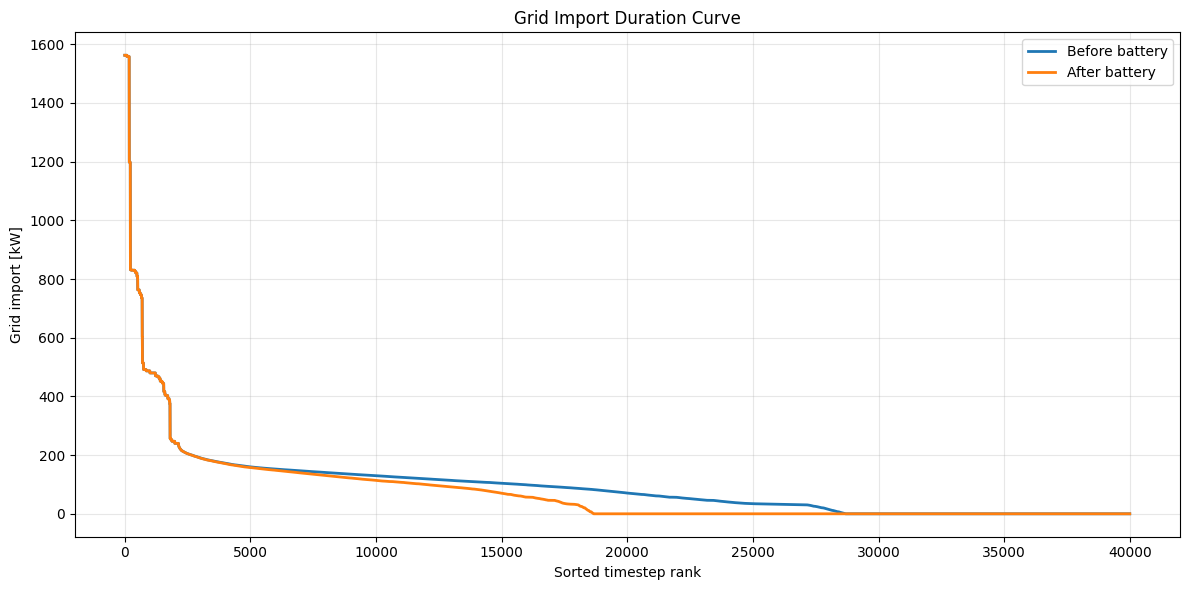

In [4]:
display(Markdown("## Grid Import Duration Curve"))

baseline_duration = df["baseline_grid_import"].sort_values(ascending=False).reset_index(drop=True)
optimized_duration = df["grid_flow"].sort_values(ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(baseline_duration.index + 1, baseline_duration, label="Before battery", linewidth=2)
ax.plot(optimized_duration.index + 1, optimized_duration, label="After battery", linewidth=2)
ax.set_xlabel("Sorted timestep rank")
ax.set_ylabel("Grid import [kW]")
ax.set_title("Grid Import Duration Curve")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
display(Markdown("## Monthly Savings and Peak Reduction"))
display(df_monthly.style.format({
    "monthly_import_cost_before": format_value,
    "monthly_import_cost_after": format_value,
    "monthly_savings": format_value,
    "monthly_peak_before": format_value,
    "monthly_peak_after": format_value,
    "monthly_peak_reduction": format_value,
}))

## Monthly Savings and Peak Reduction

,month,monthly_import_cost_before,monthly_import_cost_after,monthly_savings,monthly_peak_before,monthly_peak_after,monthly_peak_reduction
0,2024-01,"22,901.41","21,083.53","1,817.89",235.15,235.15,-0.00
1,2024-02,"16,825.42","11,637.87","5,187.55",199.24,199.24,-0.00
2,2024-03,"14,424.77","7,930.14","6,494.63",207.76,207.76,0.00
3,2024-04,"12,081.29","5,151.57","6,929.71",221.96,213.19,8.76
4,2024-05,"10,578.01","3,832.15","6,745.86",211.76,210.42,1.34
5,2024-06,"9,599.37","3,086.31","6,513.06",161.65,158.05,3.60
6,2024-07,"10,166.51","2,767.06","7,399.45",171.73,155.30,16.42
7,2024-08,"10,727.40","3,280.63","7,446.77",160.66,160.66,0.00
8,2024-09,"12,358.59","5,894.74","6,463.85",219.67,219.67,-0.00
9,2024-10,"16,674.08","12,247.36","4,426.73",234.96,234.96,0.00


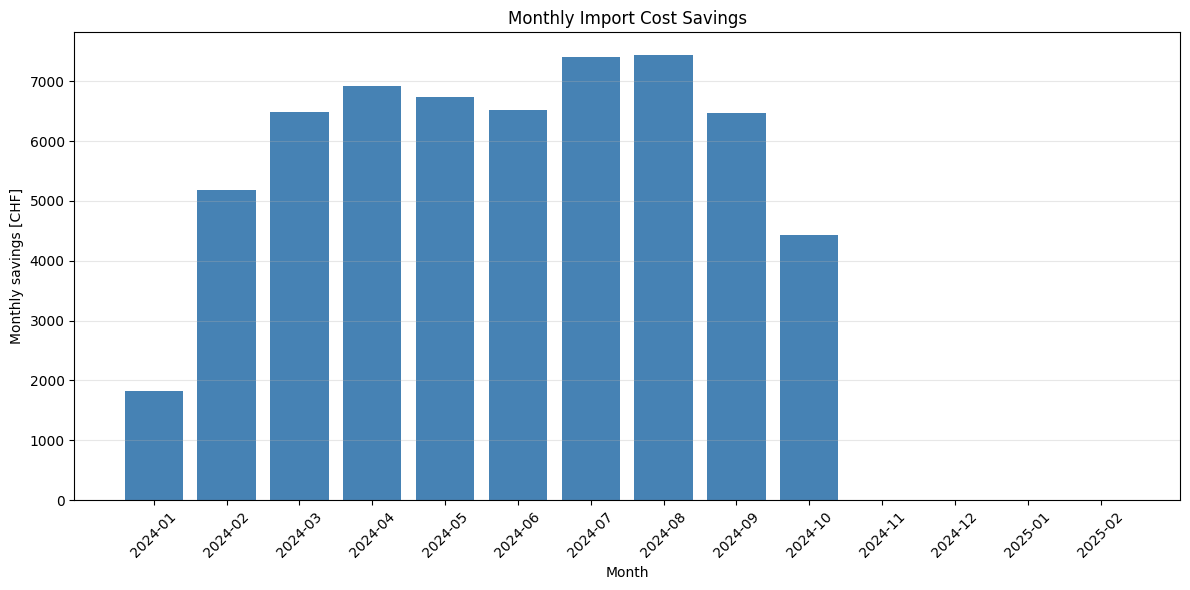

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(df_monthly["month"], df_monthly["monthly_savings"], color="steelblue")
ax.set_xlabel("Month")
ax.set_ylabel("Monthly savings [CHF]")
ax.set_title("Monthly Import Cost Savings")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
display(Markdown("## Battery Utilization Metrics"))
display(df_battery_util.style.format({"Value": format_value}))

## Battery Utilization Metrics

,Metric,Value,Unit
0,Charged energy,"647,943.41",kWh/year
1,Discharged energy,"553,991.61",kWh/year
2,Equivalent full cycles,571.32,cycles/year
3,Average state of charge,320.34,kWh
4,Minimum state of charge,0.00,kWh
5,Maximum state of charge,969.66,kWh
6,Hours near empty (<=10%),"3,540.25",hours
7,Hours near full (>=90%),443.25,hours
8,Maximum charge power used,"1,000.00",kW
9,Maximum discharge power used,979.96,kW


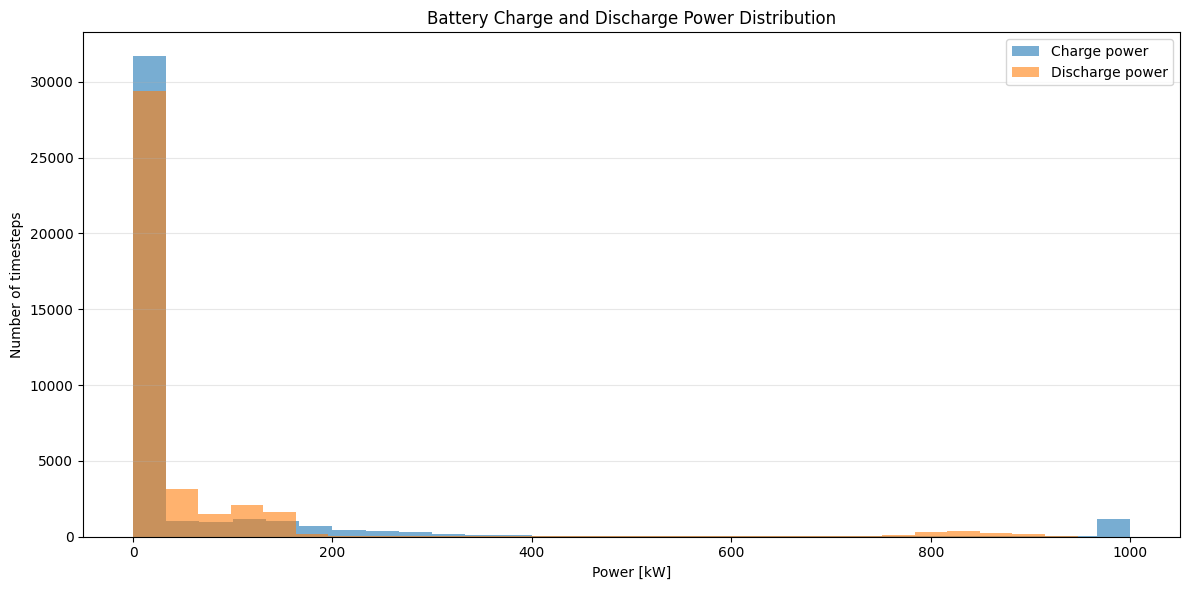

In [8]:
if {"battery_charge_power", "battery_discharge_power"}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df["battery_charge_power"], bins=30, alpha=0.6, label="Charge power", color="tab:blue")
    ax.hist(df["battery_discharge_power"], bins=30, alpha=0.6, label="Discharge power", color="tab:orange")
    ax.set_xlabel("Power [kW]")
    ax.set_ylabel("Number of timesteps")
    ax.set_title("Battery Charge and Discharge Power Distribution")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_Run the model again to generate charge/discharge power distributions for this section._"))

In [9]:
display(Markdown("## Battery Size Sensitivity"))
if df_battery_sensitivity.empty:
    display(Markdown("_Run the model again to generate the battery size sensitivity analysis._"))
else:
    display(df_battery_sensitivity.style.format({
        "battery_size_kwh": format_value,
        "annual_savings": format_value,
        "npv": format_value,
        "payback_years": format_value,
        "discounted_payback_years": format_value,
    }))

## Battery Size Sensitivity

,battery_size_kwh,optimized_battery_capacity_kwh,objective_total_cost,import_cost,annualized_battery_cost,annual_savings,npv,payback_years,discounted_payback_years,status
0,0.00,0.000000,305484.463840,294068.938726,0.000000,0.00,0.00,-,-,baseline
1,250.00,250.000000,nan,nan,112500.000000,-,-,-,-,infeasible
2,500.00,500.000000,288236.020265,257203.969831,19616.525320,"36,864.97","197,838.29",7.00,8.00,optimal
3,750.00,750.000000,284760.470580,243920.157487,29424.787980,"50,148.78","237,702.57",7.00,9.00,optimal
4,"1,000.00",1000.000000,284114.260759,233465.685006,39233.050640,"60,603.25","245,114.55",8.00,11.00,optimal
5,"1,250.00",1250.000000,284681.019227,224224.180813,49041.313299,"69,844.76","238,613.87",9.00,12.00,optimal
6,"1,500.00",1500.000000,288113.559335,217848.458261,58849.575959,"76,220.48","199,242.91",9.00,14.00,optimal
7,"1,750.00",1750.000000,295230.806090,215157.442356,68657.838619,"78,911.50","117,608.65",10.00,16.00,optimal
8,"2,000.00",2000.000000,303204.646347,213323.019954,78466.101279,"80,745.92","26,149.33",12.00,19.00,optimal


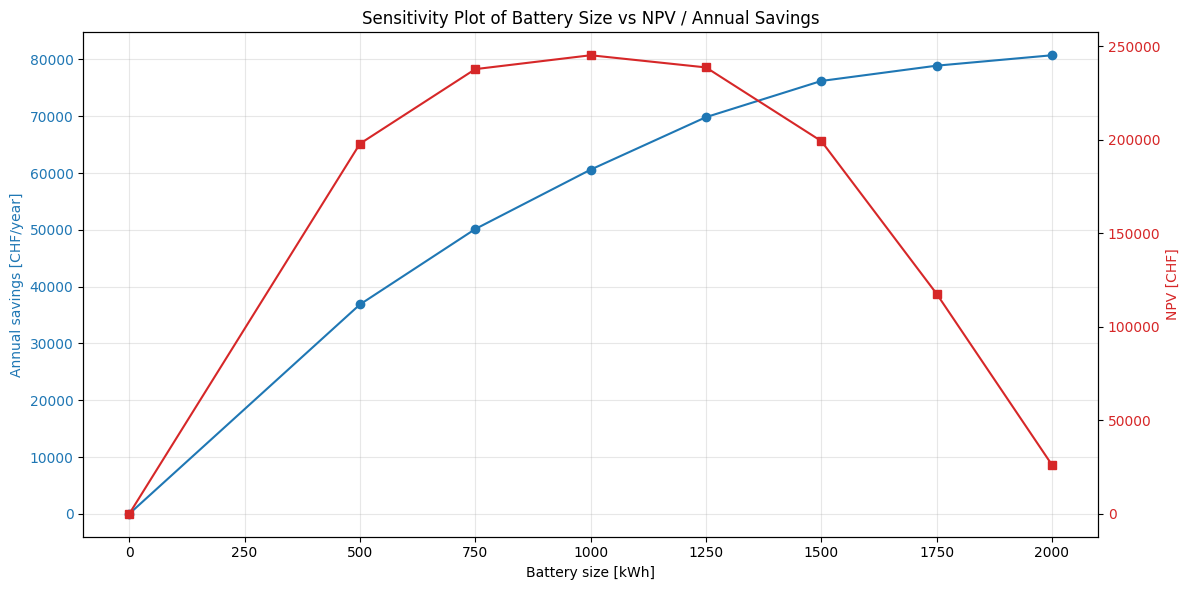

In [10]:
plot_df = df_battery_sensitivity[df_battery_sensitivity["status"].isin(["baseline", "optimal"])].copy() if not df_battery_sensitivity.empty else df_battery_sensitivity
if not plot_df.empty:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(plot_df["battery_size_kwh"], plot_df["annual_savings"], marker="o", color="tab:blue")
    ax1.set_xlabel("Battery size [kWh]")
    ax1.set_ylabel("Annual savings [CHF/year]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(plot_df["battery_size_kwh"], plot_df["npv"], marker="s", color="tab:red")
    ax2.set_ylabel("NPV [CHF]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Sensitivity Plot of Battery Size vs NPV / Annual Savings")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_No sensitivity results available yet for this run._"))

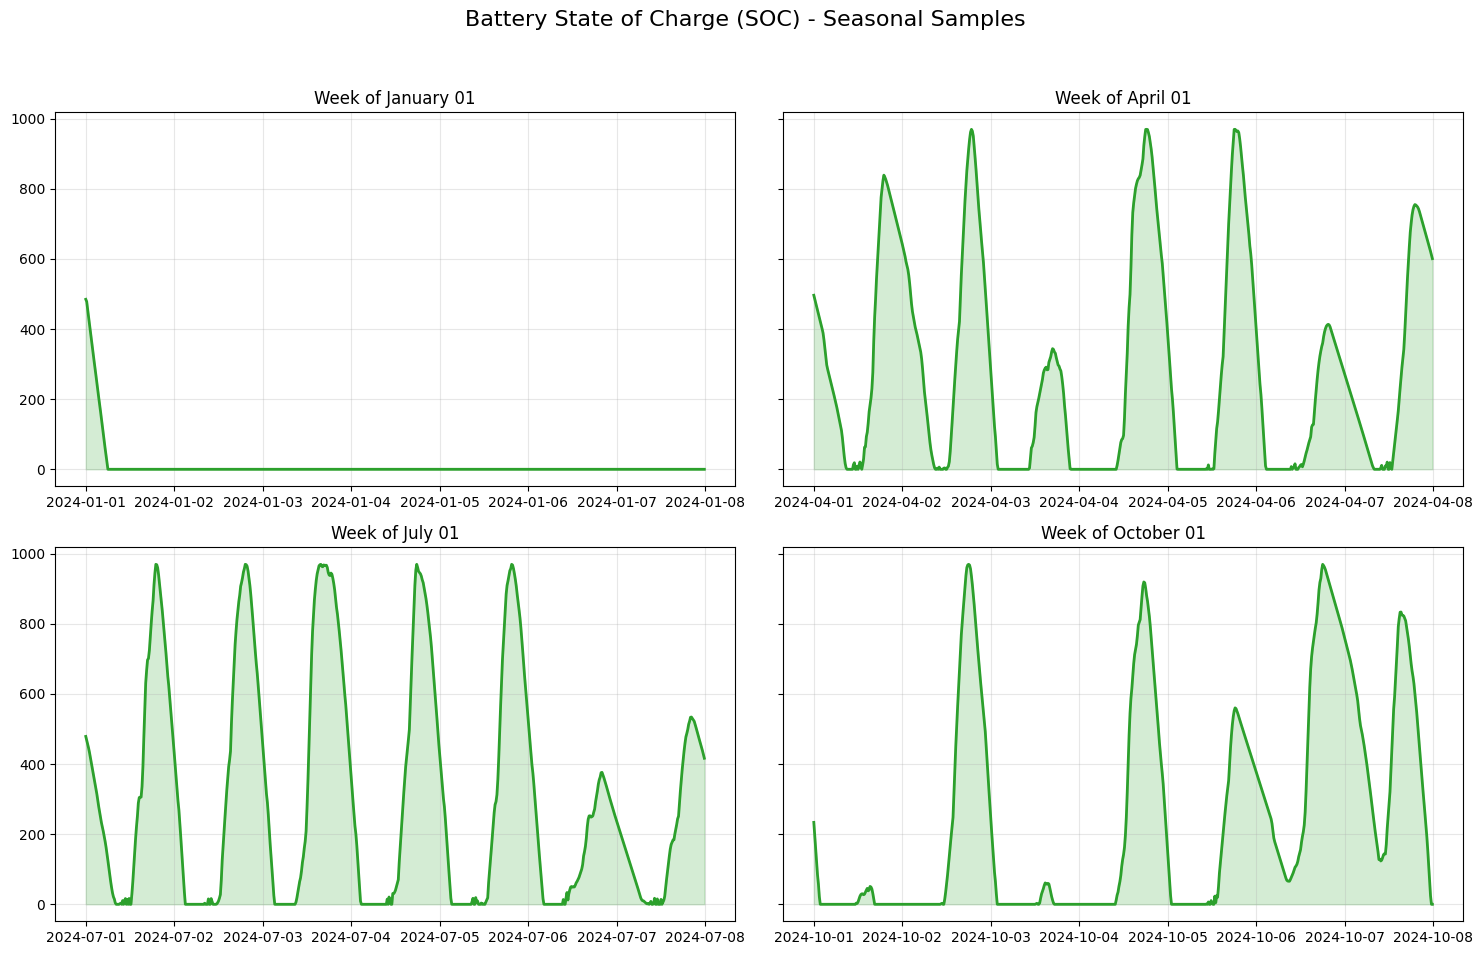

In [11]:
## 2. Battery State of Charge (Seasonal Samples)
if 'df_soc' not in globals():
    df_soc = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()
dates = [f"{df_soc['timestamp'].dt.year.iloc[0]}-01-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-04-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-07-01", 
         f"{df_soc['timestamp'].dt.year.iloc[0]}-10-01"]

for i, start_date in enumerate(dates):
    start = pd.to_datetime(start_date)
    end = start + pd.Timedelta(days=7)
    mask = (df_soc['timestamp'] >= start) & (df_soc['timestamp'] < end)
    
    ax = axes[i]
    if mask.any():
        ax.plot(df_soc.loc[mask, 'timestamp'], df_soc.loc[mask, 'battery_soc'], color='#2ca02c', lw=2)
        ax.fill_between(df_soc.loc[mask, 'timestamp'], df_soc.loc[mask, 'battery_soc'], alpha=0.2, color='#2ca02c')
        ax.set_title(f"Week of {start.strftime('%B %d')}")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, "No Data", ha='center')

plt.suptitle("Battery State of Charge (SOC) - Seasonal Samples", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

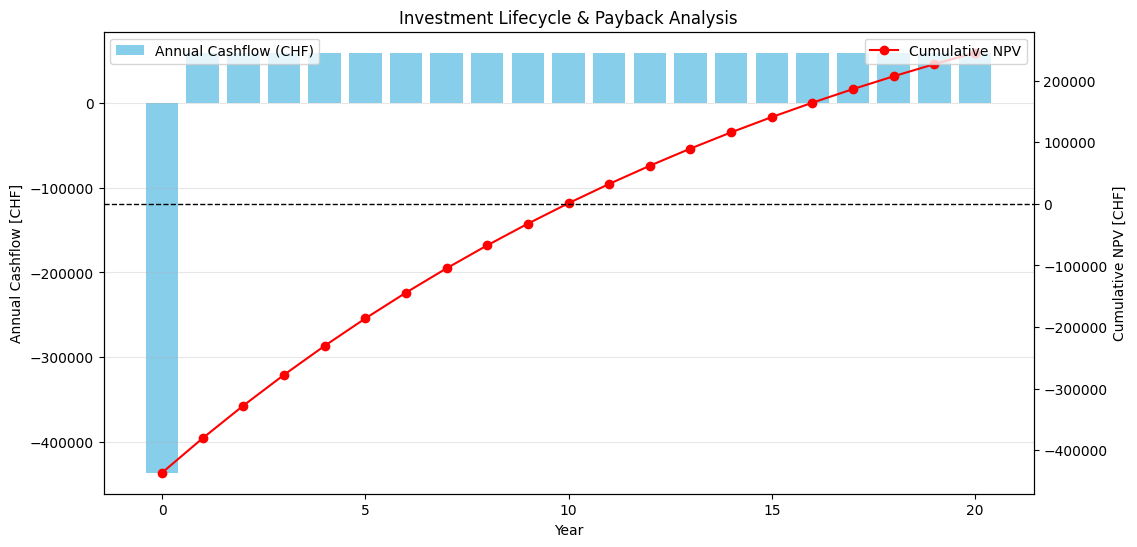

**Payback Period:** 8 years

**Discounted Payback Period:** 10 years

**Net Present Value (NPV):** CHF 245,257.73

In [12]:
## 3. Financial Projection
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_fin['year'], df_fin['cashflow'], color='skyblue', label='Annual Cashflow (CHF)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Cashflow [CHF]')

ax2 = ax1.twinx()
ax2.plot(df_fin['year'], df_fin['discounted_cashflow'].cumsum(), color='red', marker='o', label='Cumulative NPV')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_ylabel('Cumulative NPV [CHF]')

plt.title("Investment Lifecycle & Payback Analysis")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.show()

display(Markdown(f"**Payback Period:** {summary.get('payback_years', 'N/A')} years"))
display(Markdown(f"**Discounted Payback Period:** {summary.get('discounted_payback_years', 'N/A')} years"))
display(Markdown(f"**Net Present Value (NPV):** CHF {summary.get('npv', 0):,.2f}"))